In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

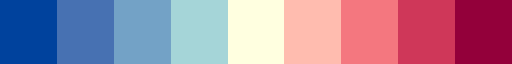

In [3]:
my_cmap

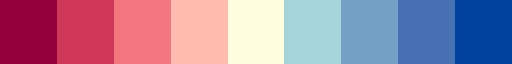

In [4]:
my_cmap_r

In [5]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

########################################################
########################################################
# Fig 1-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [6]:
rand_seed=4
np.random.seed(rand_seed)
session_name="Data/test"
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution():
    k=0.8
    return np.random.exponential(k)

u=0.6
o=0
f_interaction=lambda : uniform_distribution(u,o)
num_C=2
num_S=12
N=num_C*num_S

I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)

def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary

CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)

Folder 'Data/test' created.


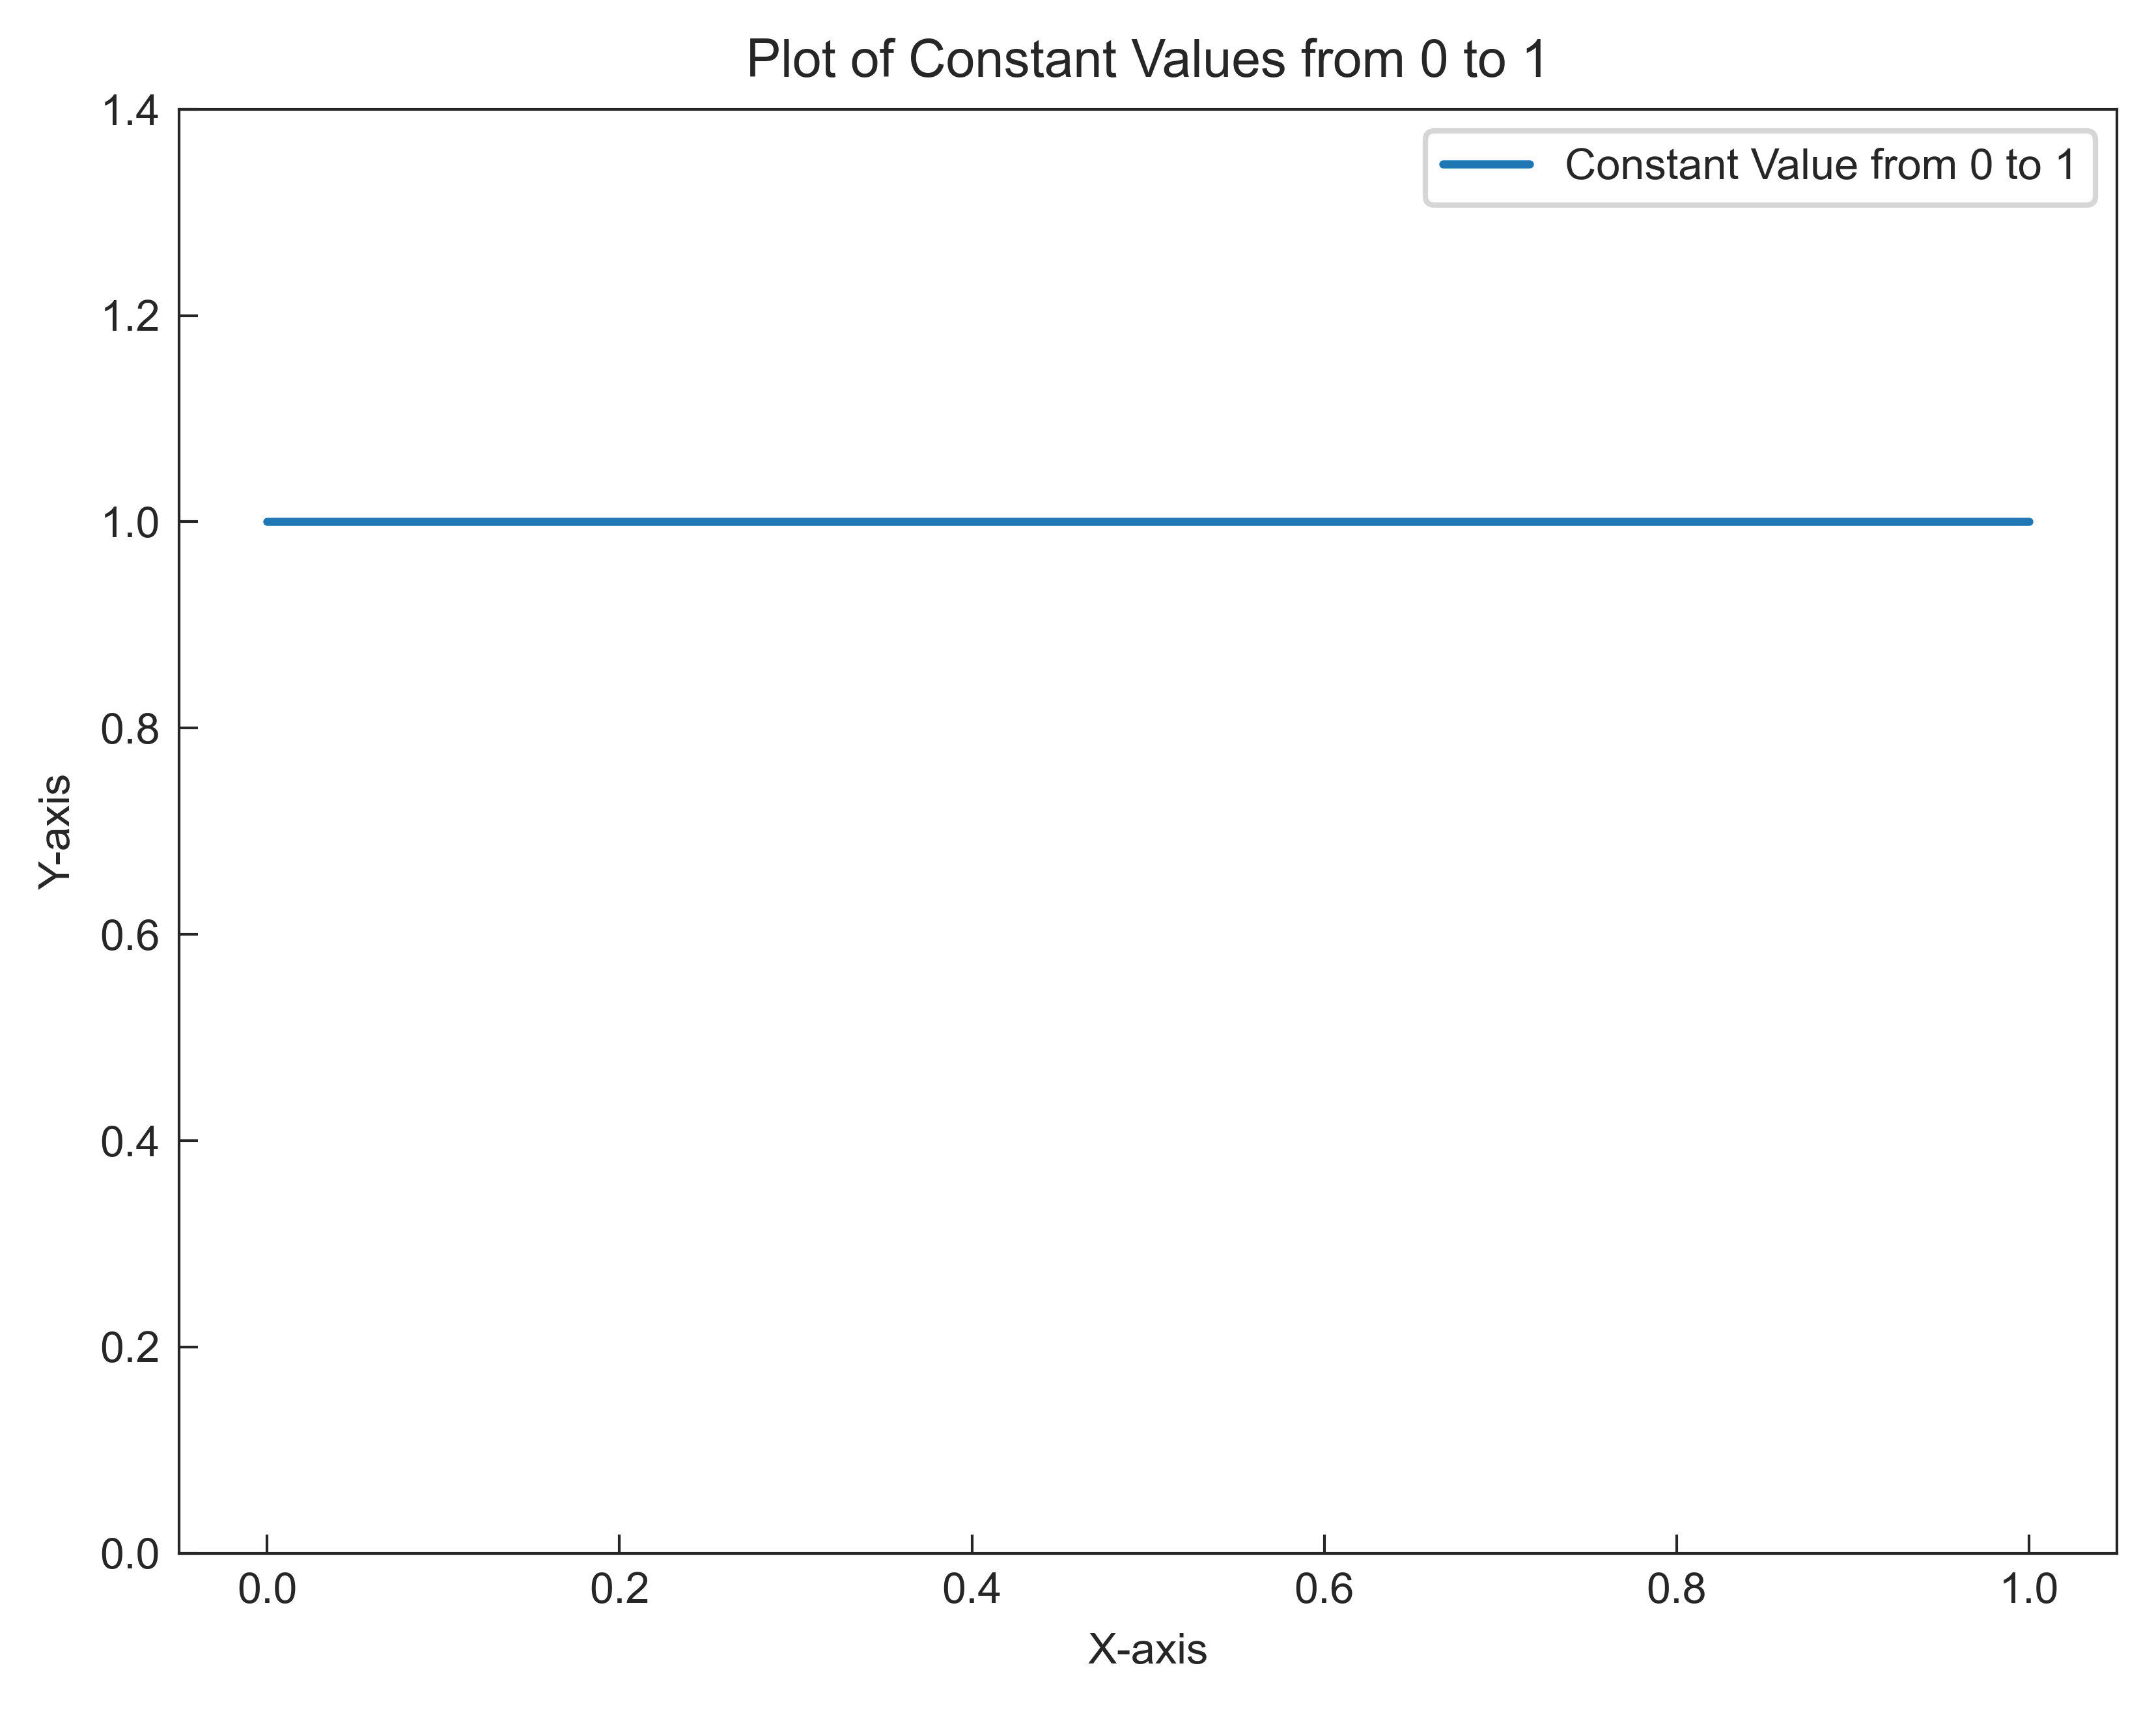

In [26]:
# Create x values from 0 to 1
x = np.linspace(0, 1, 100)  # You can adjust the number of points (e.g., 100) for smoother plotting

# Create y values (constant from 0 to 1)
y = np.ones_like(x)  # Creates an array of ones with the same shape as x

# Create the plot
plt.plot(x, y, label='Constant Value from 0 to 1')

# Set axis labels
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

# Set the y-axis limit from 0 to 1
plt.ylim(0, 1.4)

# Add a legend
plt.legend()

# Show the plot
plt.title('Plot of Constant Values from 0 to 1')
#plt.grid(True)
plt.show()

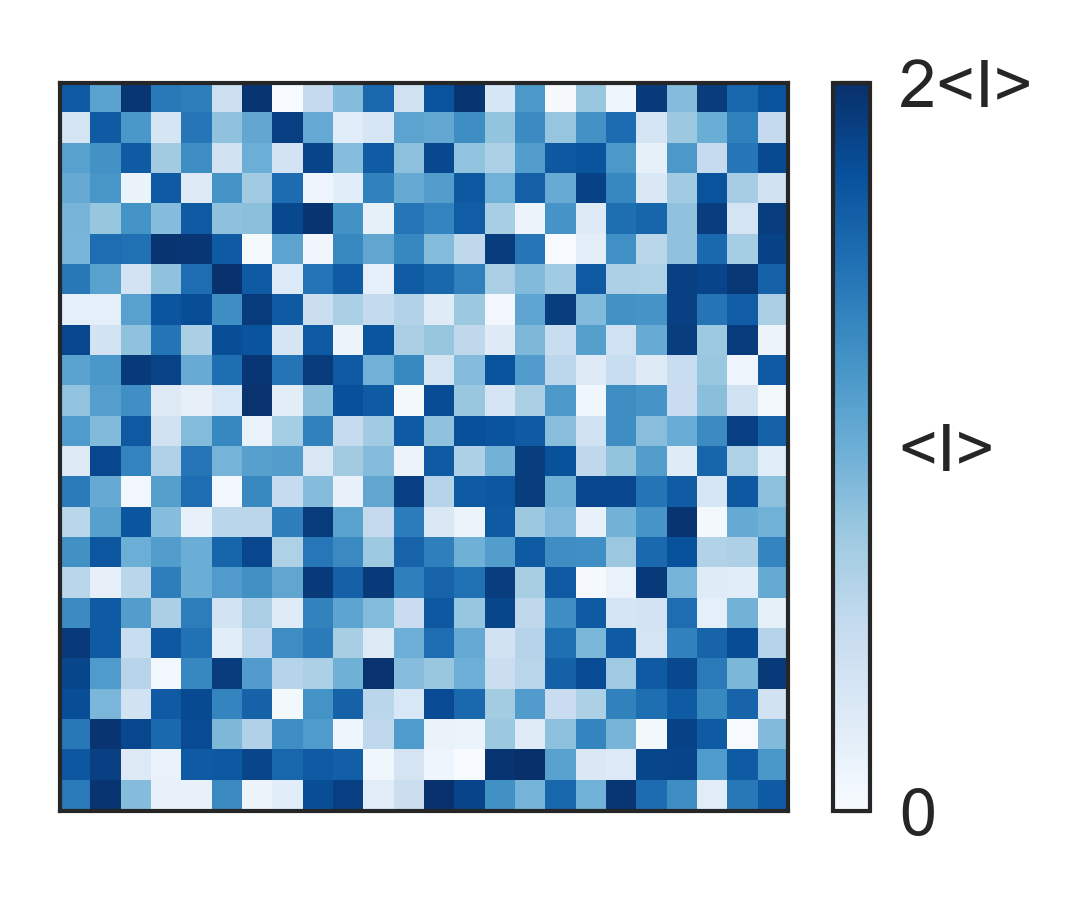

In [23]:
# Create a heatmap using the imshow function
matrix=I
f, ax = plt.subplots(1, figsize=(50*mm,40*mm), facecolor='w', edgecolor='k')

img=plt.imshow(matrix, cmap='Blues', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap
cbar = plt.colorbar(img, ticks=[np.min(matrix), np.max(matrix) / 2, np.max(matrix)], format='%.2f')
cbar.ax.set_yticklabels(['0', f'<I>', f'2<I>'])

# Add labels and title

# Display the grid
plt.grid(False)
plt.xticks([])
plt.yticks([])

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-1_I_hetamap.svg', bbox_inches='tight')

In [8]:
np.random.seed(rand_seed)
t=np.linspace(0, 5000, 10000)
threshold=1e-3
y=np.random.rand(N)*0.1
c1=run_lotka_volterra_dynamics(y, t, CommunitiesLibrary[0,:], I, g, k)
c2=run_lotka_volterra_dynamics(y, t, CommunitiesLibrary[1,:], I, g, k)

y1=c1[-1]
y2=c2[-1]
y1[y1<threshold]=0
y2[y2<threshold]=0
y3=np.array(y1.tolist()+y2.tolist())
survived=y3>threshold
c3=run_lotka_volterra_dynamics(y3, t, survived, I, g, k)
c3_temp=np.zeros((len(t), 24))
for i,idx in enumerate(np.where(survived)[0]):
    c3_temp[:,idx]=c3[:,i]
c3=c3_temp

ValueError: too many values to unpack (expected 2)

In [ ]:
c=c1
f, ax = plt.subplots(1, figsize=(50*mm,40*mm), facecolor='w', edgecolor='k')
base_color=my_cmap(0)[:3]
colors = [
    my_cmap(0)[:3],  # darker blue
    my_cmap(1)[:3],  # blue
    np.array(my_cmap(2)[:3])*0.8,
    np.array(my_cmap(3)[:3])*0.9,# lighter blue
]
temp_cmap=LinearSegmentedColormap.from_list('custom_cmap', colors)

for i in range(12):
    plt.plot(t,c[:,i], linewidth=0.7,color=temp_cmap(i/12))
plt.axhline(y=0.001, linewidth=0.7, linestyle='dotted', color='black', dashes=[3, 3])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('time')
plt.ylabel('$N_i$')
plt.ylim(3*1e-4, 1)

f.savefig('Figure/Fig_2-1_Dynamics_c1.svg', bbox_inches='tight')

In [ ]:
c=c2
f, ax = plt.subplots(1, figsize=(50*mm,40*mm), facecolor='w', edgecolor='k')
base_color=my_cmap(0)[:3]
colors = [
    np.array(my_cmap(6))[:3]*0.8,  # darker blue
    np.array(my_cmap(7))[:3]*0.9,  # blue
    np.array(my_cmap(8)[:3])*1,
    np.array(my_cmap(9)[:3])*1,# lighter blue
]
temp_cmap=LinearSegmentedColormap.from_list('custom_cmap', colors)

for i in range(12):
    plt.plot(t,c[:,i], linewidth=0.7,color=temp_cmap(i/12))
plt.axhline(y=0.001, linewidth=0.7, linestyle='dotted', color='black', dashes=[3, 3])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('time')
plt.ylabel('$N_i$')
plt.ylim(3*1e-4, 1)
f.savefig('Figure/Fig_2-1_Dynamics_c2.svg', bbox_inches='tight')

In [ ]:
c3.shape

In [ ]:
np.sum(survived[:12])

In [ ]:
c=c3
f, ax = plt.subplots(1, figsize=(50*mm,40*mm), facecolor='w', edgecolor='k')
base_color=my_cmap(0)[:3]
colors1 = [
    my_cmap(0)[:3],  # darker blue
    my_cmap(1)[:3],  # blue
    np.array(my_cmap(2)[:3])*0.8,
    np.array(my_cmap(3)[:3])*0.9,# lighter blue
]
temp_cmap1=LinearSegmentedColormap.from_list('custom_cmap', colors1)

colors2 = [
    np.array(my_cmap(6))[:3]*0.8,  # darker blue
    np.array(my_cmap(7))[:3]*0.9,  # blue
    np.array(my_cmap(8)[:3])*1,
    np.array(my_cmap(9)[:3])*1,# lighter blue
]
temp_cmap2=LinearSegmentedColormap.from_list('custom_cmap', colors2)


for i in range(12):
    plt.plot(t,c[:,i], linewidth=0.7,color=temp_cmap1(i/12))
for i in range(12):
    plt.plot(t,c[:,12+i], linewidth=0.7,color=temp_cmap2(i/12))
plt.axhline(y=0.001, linewidth=0.7, linestyle='dotted', color='black', dashes=[3, 3])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('time')
plt.ylabel('$N_i$')
plt.ylim(3*1e-4, 1)

f.savefig('Figure/Fig_2-1_Dynamics_mix.svg', bbox_inches='tight')